In [2]:
%load_ext autoreload
%autoreload 2

# Goldfish loss: full/gdn vs full-goldfish / gdn-goldfish
Memorization comparison: whether goldfish loss prevents memorization, especially for highly susceptible to memorization gdn

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid
from attn_bench.plotting.heatmap import plot_models_heatmap_panel

## Load memorization results

In [2]:
MODELS = ['full-scf8', 'full-goldfish-scf8', 'gdn', 'gdn-goldfish']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

## Rouge-L
### Offsets

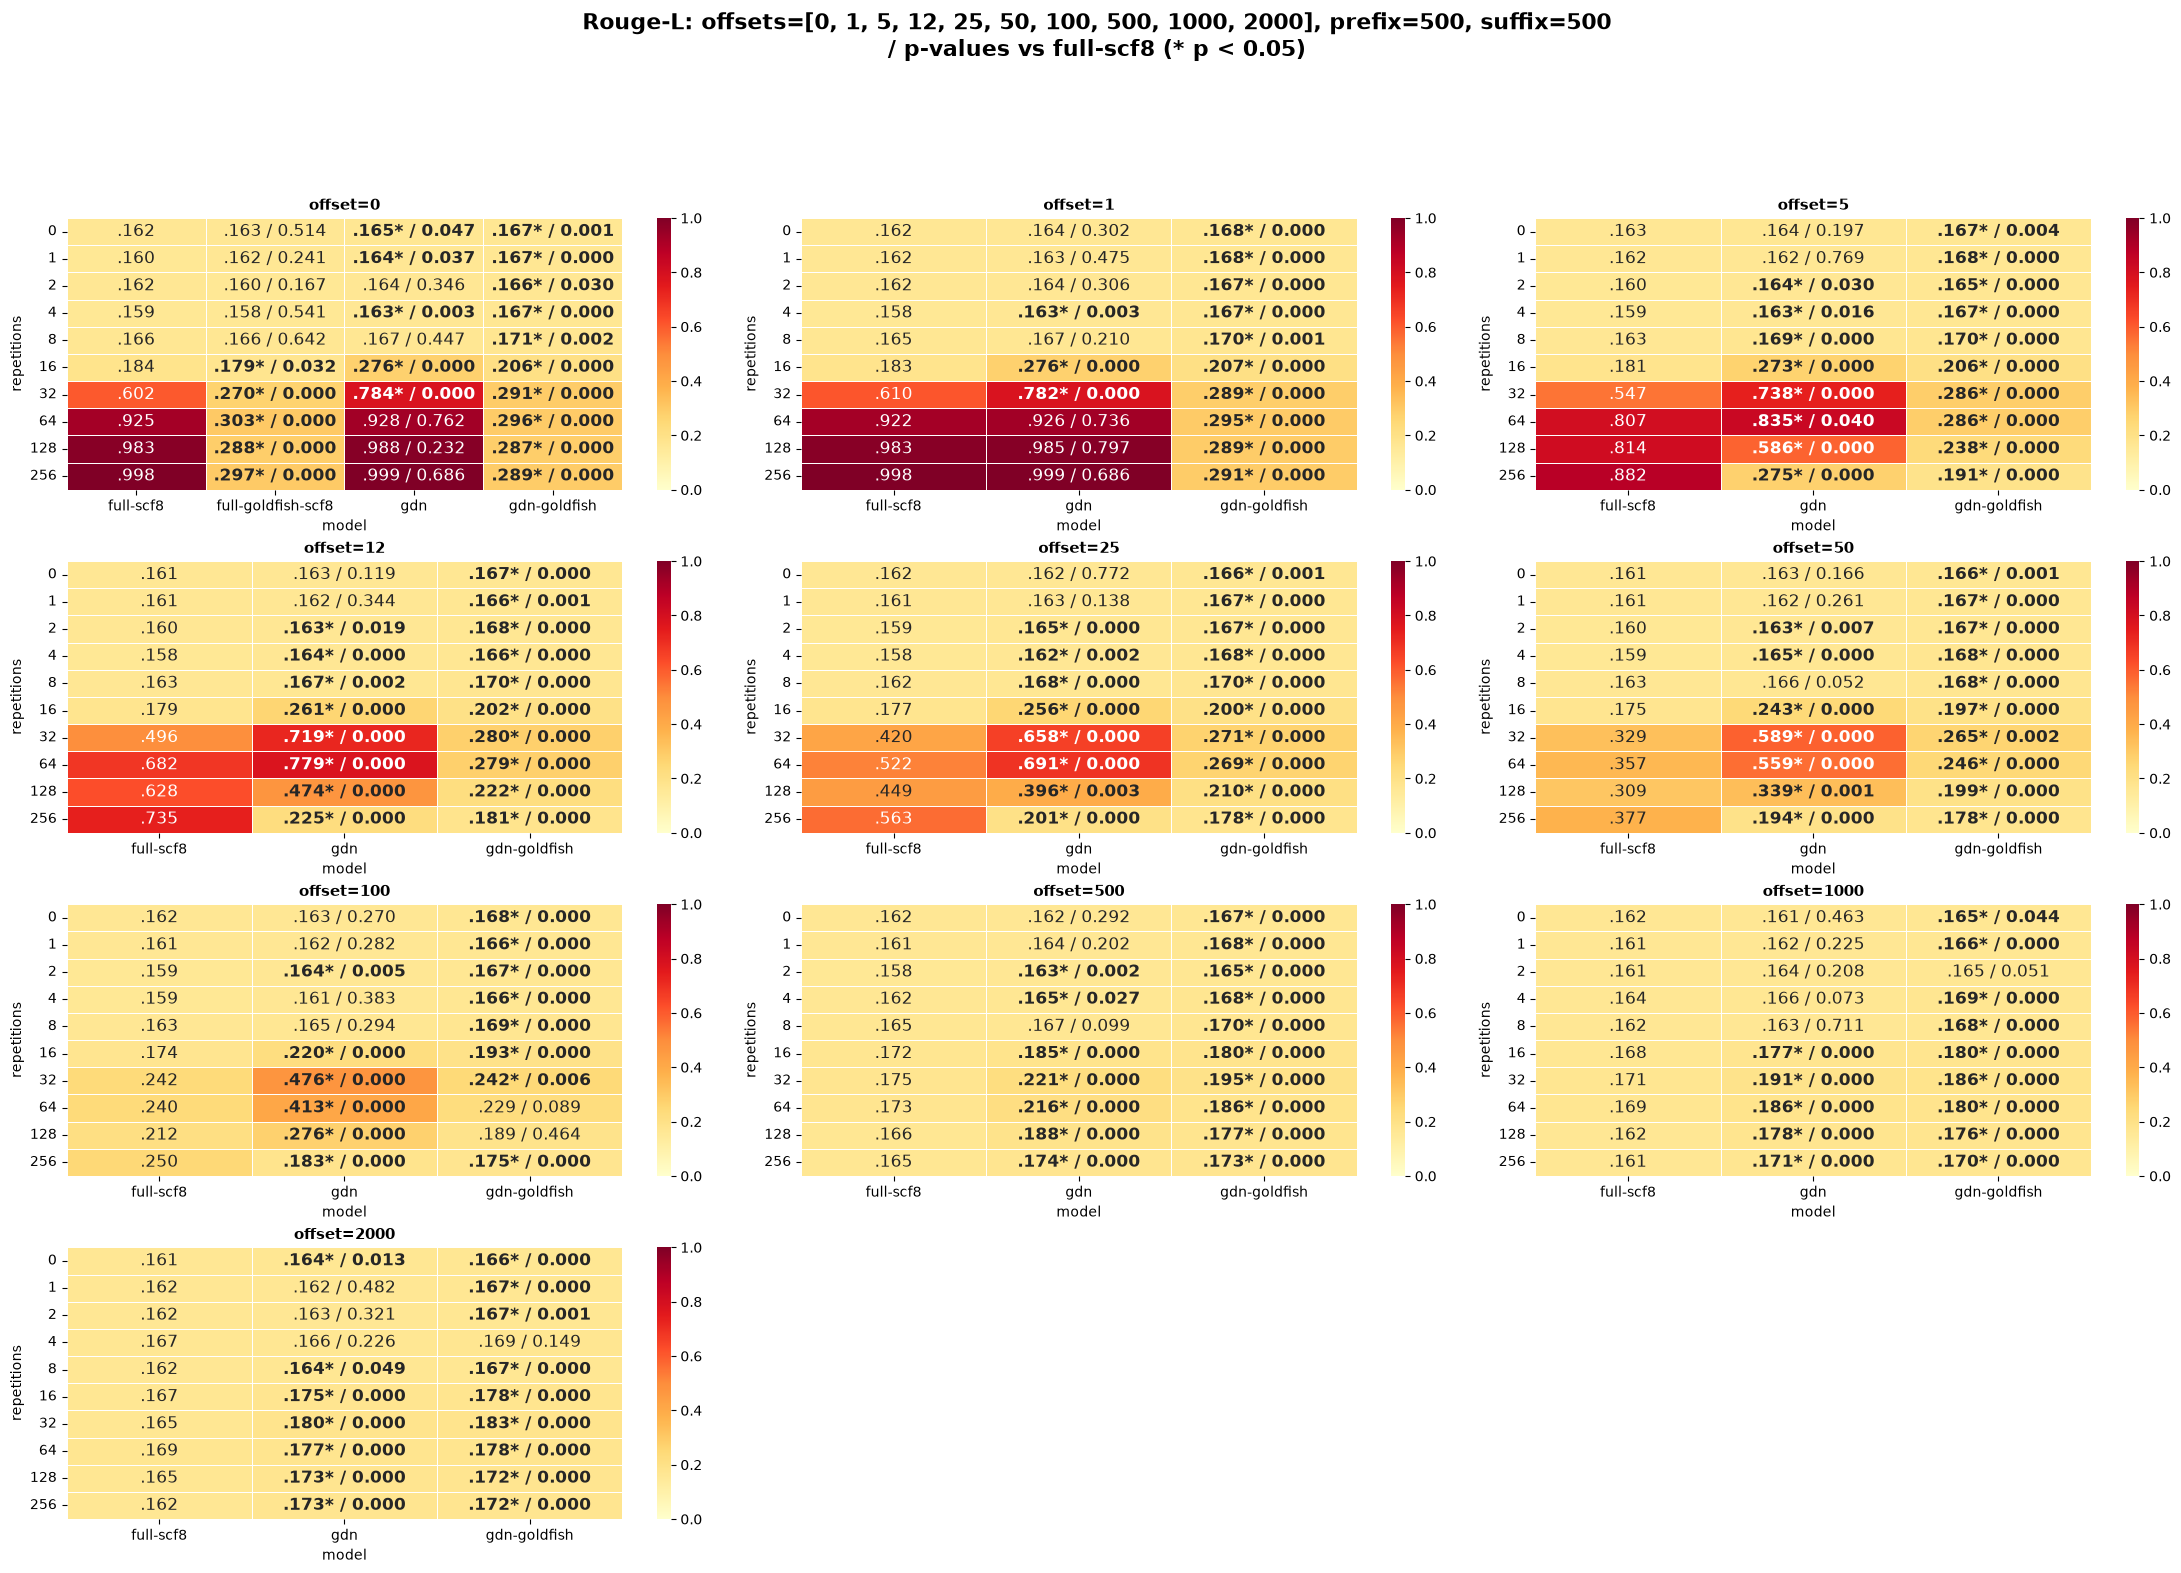

In [3]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', models=MODELS, panels='offset', values=OFFSETS, fixed_prefix=500, fixed_suffix=500, ncols=3,
    reference='full-scf8',
)

### Prefixes

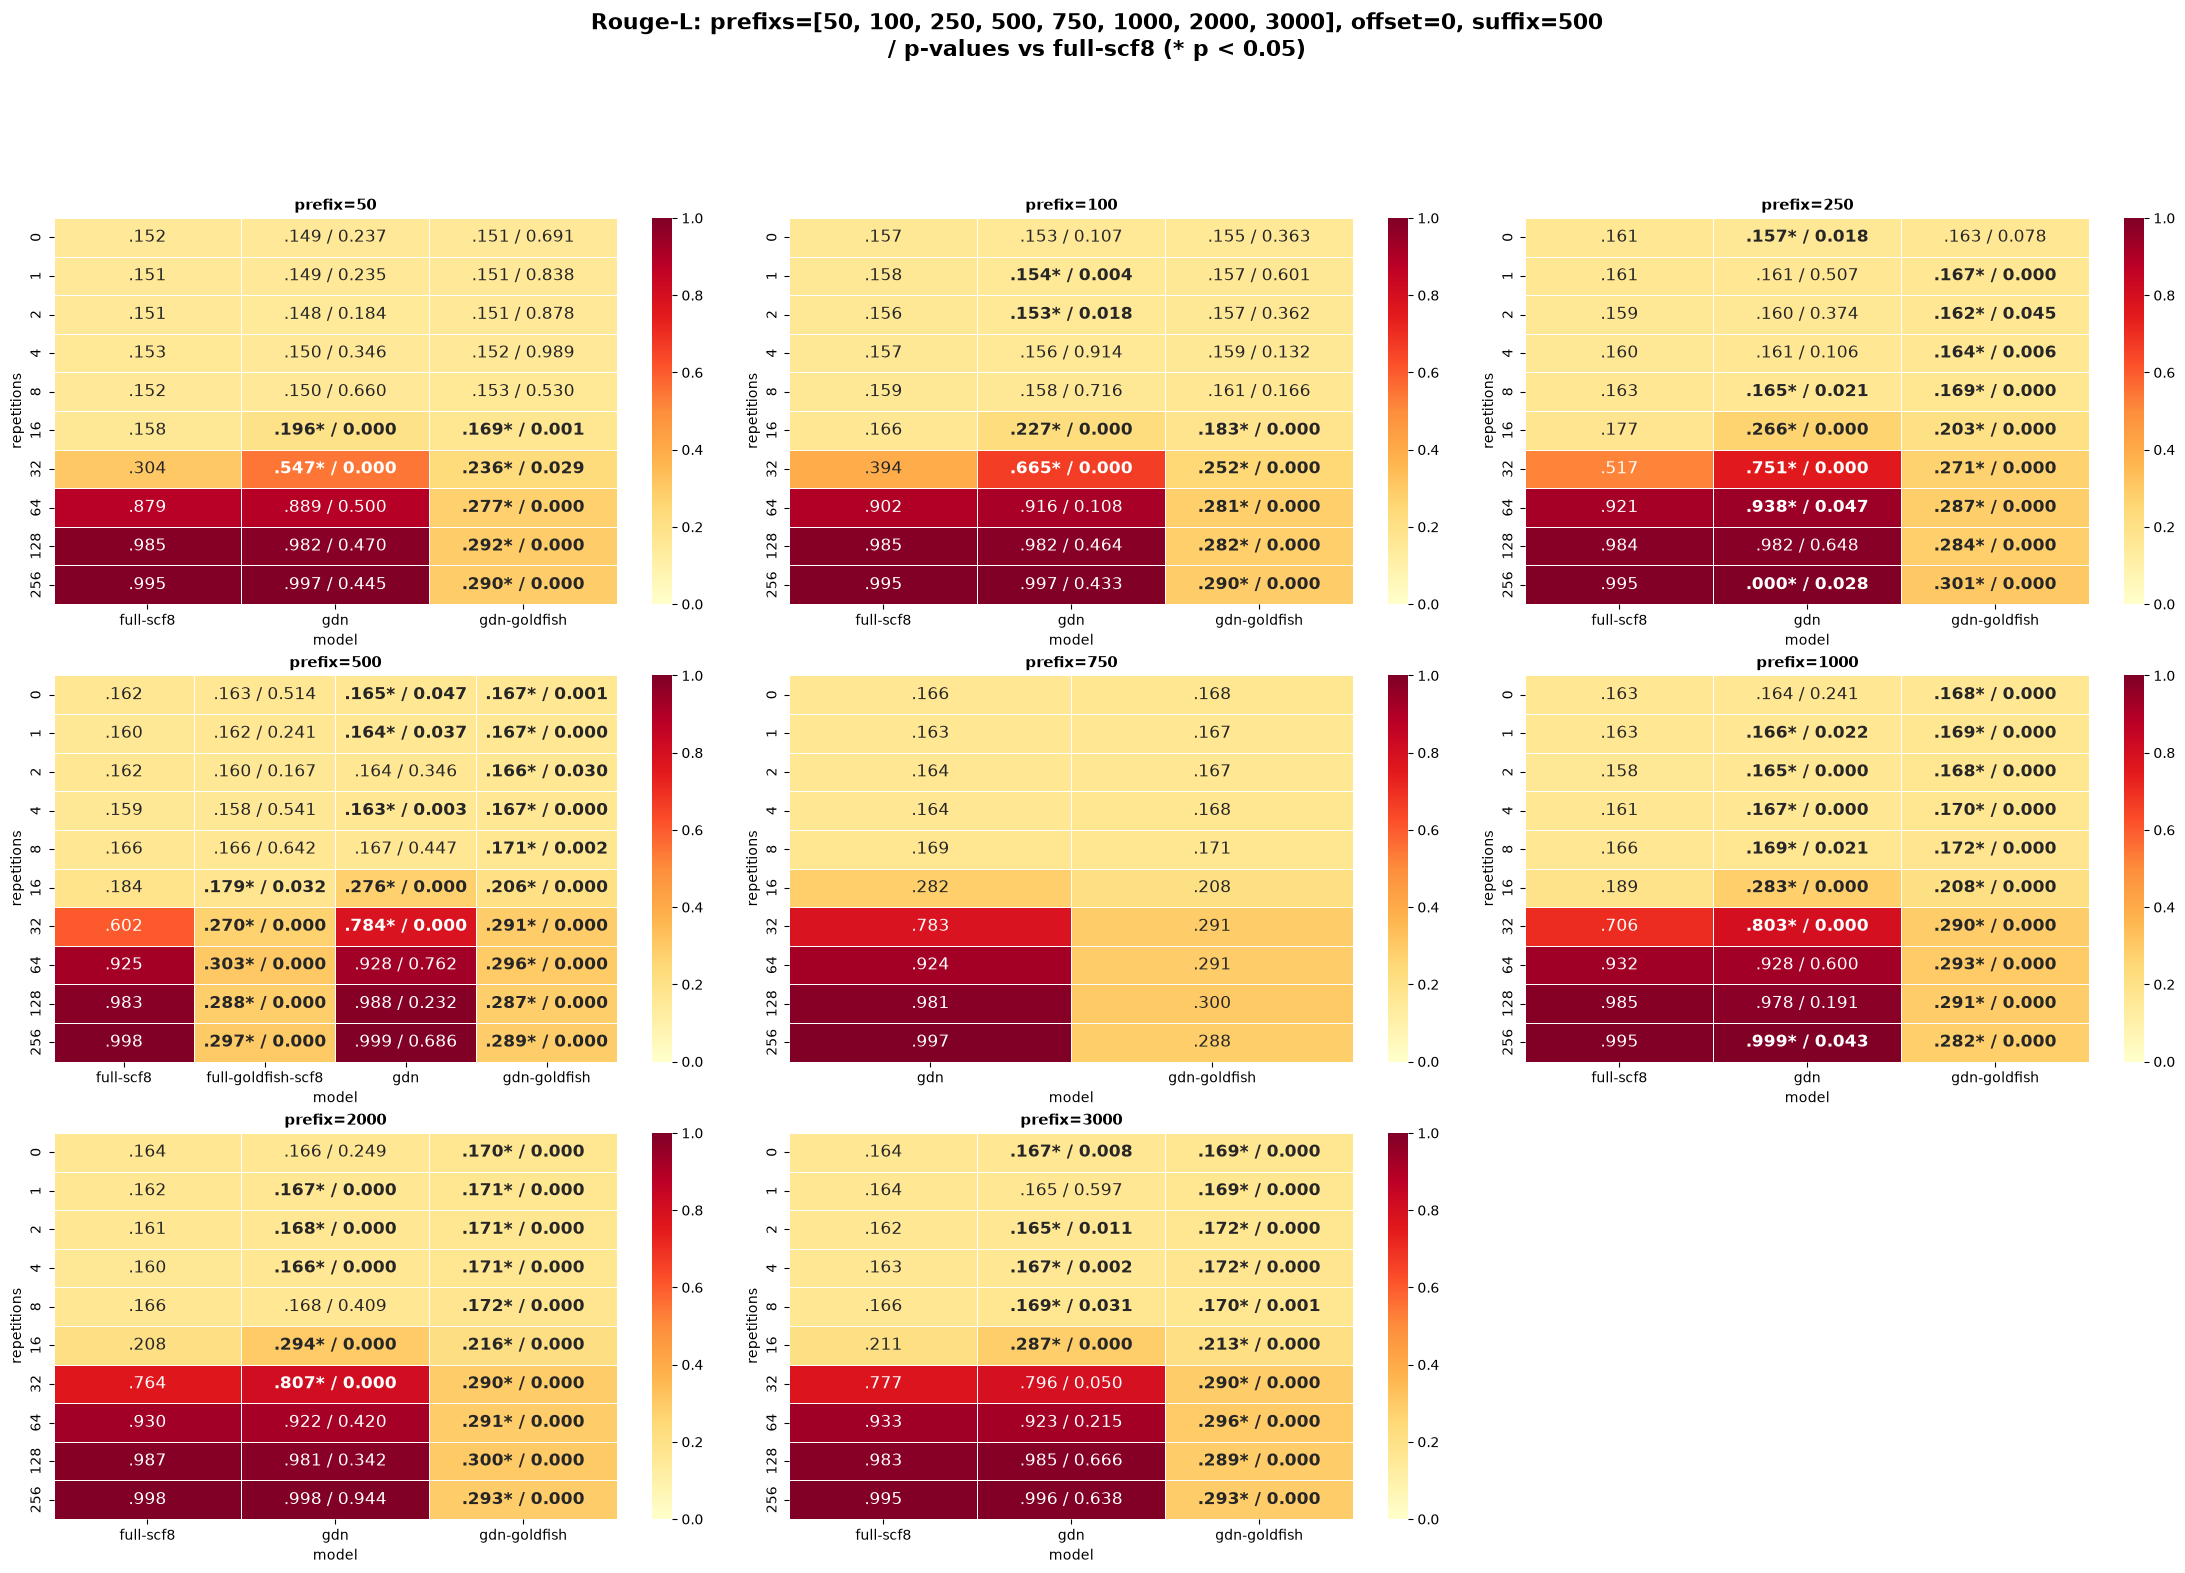

In [4]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', models=MODELS, panels='prefix', values=PREFIXES, fixed_offset=0, fixed_suffix=500, ncols=3,
    reference='full-scf8',
)